# Parte 2 — Series Temporales, Feature Engineering y Modelado

## Definición del problema de forecasting

El objetivo del Grupo 7 es desarrollar un modelo capaz de pronosticar la
potencia activa global promedio del hogar para la próxima hora.

- **Variable objetivo:** `Global_active_power`
- **Frecuencia original:** 1 minuto
- **Frecuencia de modelado:** 1 hora
- **Agregación del target:** promedio horario
- **Horizonte de predicción:** t + 1 hora
- **Métricas principales:** MAE y RMSE

Para cada hora que se desea pronosticar, el modelo utilizará únicamente
información disponible en horas anteriores, evitando el uso de información
contemporánea o futura que pueda producir data leakage.

# 1. Importar librerías

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 2. Ejecutar la Ingesta

In [2]:
%run src/ingestion/ingest.py

El archivo ZIP ya existe.
El dataset ya fue extraído.
Ingesta completada
Dataset disponible en: C:\GITHUB\Proyecto-Household-Power-G7\data\raw\household_power_consumption.txt


# 3. Definir el Archivo

In [3]:
ROOT_DIR = Path.cwd()

RAW_FILE = (
    ROOT_DIR
    / "data"
    / "raw"
    / "household_power_consumption.txt"
)

if not RAW_FILE.exists():
    raise FileNotFoundError(
        "No se encontró el archivo de datos después de ejecutar la ingesta."
    )

print("Dataset:", RAW_FILE)

Dataset: c:\GITHUB\Proyecto-Household-Power-G7\data\raw\household_power_consumption.txt


# 4. Cargar el RAW

In [4]:
columnas = [
    "Date",
    "Time",
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

df = pd.read_csv(
    RAW_FILE,
    sep=";",
    na_values=["?"],
    usecols=columnas,
    low_memory=False,
)

print("Dimensiones:", df.shape)

display(df.head())

Dimensiones: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


# 5. Preparación de la Serie Temporal

## 5.1 Construcción del índice temporal

In [5]:
df["datetime"] = pd.to_datetime(
    df["Date"].astype(str)
    + " "
    + df["Time"].astype(str),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce",
)

df = (
    df
    .drop(columns=["Date", "Time"])
    .set_index("datetime")
    .sort_index()
)

display(df.head())

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


Comprobamos que el índice temporal quedó bien:

In [6]:
print(
    "Índice ordenado:",
    df.index.is_monotonic_increasing
)

print(
    "Timestamps duplicados:",
    df.index.duplicated().sum()
)

print(
    "Fecha inicial:",
    df.index.min()
)

print(
    "Fecha final:",
    df.index.max()
)

Índice ordenado: True
Timestamps duplicados: 0
Fecha inicial: 2006-12-16 17:24:00
Fecha final: 2010-11-26 21:02:00


Lo que indica el código anterior no sustituye el análisis del Notebook 01; simplemente se comprueba que la transformación no rompió nada.

**Resultado:** La conversión de `Date` y `Time` a un índice `datetime` fue
exitosa. El índice se encuentra ordenado cronológicamente, no presenta
timestamps duplicados y conserva el mismo período temporal identificado
durante el diagnóstico del Notebook 01.

## 5.2 Resampling y creación de la serie horaria

### Criterio de agregación horaria

El dataset original contiene observaciones con frecuencia de un minuto. Para
el modelado se decidió trabajar a frecuencia horaria con el objetivo de
reducir el volumen de datos sin perder los patrones intradiarios identificados
durante el EDA.

Las variables eléctricas no poseen todas la misma unidad, por lo que la
agregación horaria se realiza de acuerdo con su significado físico:

- `Global_active_power`: promedio horario.
- `Global_reactive_power`: promedio horario.
- `Voltage`: promedio horario.
- `Global_intensity`: promedio horario.
- `Sub_metering_1`: suma horaria.
- `Sub_metering_2`: suma horaria.
- `Sub_metering_3`: suma horaria.

El promedio se utiliza para las variables que representan magnitudes medidas
durante el minuto, mientras que los submedidores se agregan mediante suma
porque representan energía en Wh registrada durante cada intervalo.

In [7]:
df_hourly = pd.DataFrame({
    "Global_active_power":
        df["Global_active_power"].resample("h").mean(),

    "Global_reactive_power":
        df["Global_reactive_power"].resample("h").mean(),

    "Voltage":
        df["Voltage"].resample("h").mean(),

    "Global_intensity":
        df["Global_intensity"].resample("h").mean(),

    "Sub_metering_1":
        df["Sub_metering_1"].resample("h").sum(min_count=1),

    "Sub_metering_2":
        df["Sub_metering_2"].resample("h").sum(min_count=1),

    "Sub_metering_3":
        df["Sub_metering_3"].resample("h").sum(min_count=1),
})

In [ ]:
# Contar cuántos minutos válidos tiene cada hora
df_hourly["valid_minutes"] = (
    df["Global_active_power"]
    .resample("h")
    .count()
)

df_hourly["coverage_pct"] = (
    df_hourly["valid_minutes"] / 60 * 100
)

display(df_hourly.head())

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,valid_minutes,coverage_pct
datetime,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,19.0,607.0,36,60.0
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,403.0,1012.0,60,100.0
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,86.0,1001.0,60,100.0
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.0,1007.0,60,100.0
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,25.0,1033.0,60,100.0


## 5.3 Evaluación de la cobertura horaria

In [9]:
# Estudiar la cobertura horaria
distribucion_cobertura = (
    df_hourly["valid_minutes"]
    .value_counts()
    .sort_index()
)

display(distribucion_cobertura)

valid_minutes
0       421
2         2
3         1
9         2
21        2
25        1
28        2
29        1
30        1
32        1
36        3
39        1
47        1
48        1
49        2
52        2
53        2
54        1
56        3
57        1
58       15
59       38
60    34085
Name: count, dtype: int64

In [10]:
print(
    "Horas totales:",
    len(df_hourly)
)

print(
    "Horas completas:",
    (df_hourly["valid_minutes"] == 60).sum()
)

print(
    "Horas sin ninguna medición:",
    (df_hourly["valid_minutes"] == 0).sum()
)

print(
    "Horas parcialmente observadas:",
    (
        (df_hourly["valid_minutes"] > 0)
        & (df_hourly["valid_minutes"] < 60)
    ).sum()
)

Horas totales: 34589
Horas completas: 34085
Horas sin ninguna medición: 421
Horas parcialmente observadas: 83


### Hallazgos de cobertura horaria

Después del resampling se obtuvieron 34,589 intervalos horarios.

- **34,085 horas (≈98.54%)** contienen las 60 observaciones esperadas.
- **421 horas** no contienen ninguna medición eléctrica válida.
- **83 horas** poseen cobertura parcial, es decir, contienen entre 1 y 59
  observaciones válidas.

Estos resultados muestran que la gran mayoría de la serie presenta cobertura
completa. Los problemas de datos faltantes se concentran en un número reducido
de intervalos horarios.

In [11]:
# Eliminación de horas incompletas por los límites del dataset
df_hourly = df_hourly.iloc[1:-1].copy()

### Tratamiento de las horas límite

La primera y la última observación horaria se excluyen del análisis debido a
que no representan horas completas por diseño del dataset.

La primera observación comienza a las 17:24 del 16/12/2006 y la última termina
a las 21:02 del 26/11/2010. Su cobertura parcial no corresponde a un problema
de calidad o pérdida de datos, sino a los límites naturales del período de
recolección.

Por esta razón, ambas observaciones se eliminan antes de evaluar la cobertura
de las horas internas de la serie.

## 5.4 Definición de horas válidas

Para que el promedio horario represente adecuadamente el comportamiento
eléctrico durante la hora, se establece un criterio mínimo de cobertura.

Cada intervalo horario debería contener 60 observaciones, correspondientes a
las mediciones minuto a minuto del dataset original.

Se considera una **hora válida** aquella que contiene al menos el **90% de las
mediciones esperadas**, equivalente a:

$$
60 \times 0.90 = 54
$$

Por tanto:

- **54–60 minutos válidos:** la hora se considera suficientemente
  representada.
- **0–53 minutos válidos:** la hora se considera de cobertura insuficiente.

La elección del 90% se basa en el análisis de cobertura realizado previamente.
La gran mayoría de las horas posee 60 observaciones y, entre las horas
parcialmente observadas, muchas contienen 58 o 59 registros. El criterio
permite conservar horas casi completas evitando representar un intervalo
horario mediante un número reducido de mediciones.

**Nota sobre los submedidores:** En las horas con cobertura parcial aceptada
(54–59 minutos), las sumas de `Sub_metering_1`, `Sub_metering_2` y
`Sub_metering_3` corresponden únicamente a los minutos observados y podrían
subestimar ligeramente la energía horaria real. Estas variables no se
utilizarán automáticamente como predictores sin evaluar previamente este
efecto durante el Feature Engineering.

In [12]:
MIN_VALID_MINUTES = 54

horas_baja_cobertura = (
    df_hourly["valid_minutes"] < MIN_VALID_MINUTES
)

print(
    "Horas con cobertura insuficiente:",
    horas_baja_cobertura.sum()
)

print(
    "Porcentaje de horas con cobertura insuficiente:",
    round(
        horas_baja_cobertura.mean() * 100,
        2
    ),
    "%"
)

Horas con cobertura insuficiente: 444
Porcentaje de horas con cobertura insuficiente: 1.28 %


### Tratamiento de las horas con cobertura insuficiente

Las horas clasificadas con cobertura insuficiente no se eliminan del índice
temporal. En su lugar, sus variables eléctricas se marcan como valores
faltantes (`NaN`).

Esta decisión permite conservar la continuidad de la serie horaria. Mantener
todos los timestamps será especialmente importante durante la creación de
variables rezagadas (`lags`), ya que eliminar una hora podría provocar que dos
observaciones separadas por más de una hora fueran interpretadas
incorrectamente como observaciones consecutivas.

In [13]:
columnas_electricas = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

df_hourly.loc[
    horas_baja_cobertura,
    columnas_electricas
] = np.nan

In [14]:
missing_hourly = pd.DataFrame({
    "Missing": df_hourly.isna().sum(),
    "Porcentaje": (
        df_hourly.isna().mean() * 100
    ).round(2),
})

display(missing_hourly)

,Missing,Porcentaje
Global_active_power,444,1.28
Global_reactive_power,444,1.28
Voltage,444,1.28
Global_intensity,444,1.28
Sub_metering_1,444,1.28
Sub_metering_2,444,1.28
Sub_metering_3,444,1.28
valid_minutes,0,0.00
coverage_pct,0,0.00


## 5.5 Calidad de datos posterior al resampling 

Después de transformar las observaciones minuto a minuto a frecuencia horaria
y aplicar el criterio mínimo de cobertura del 90%, se realiza una nueva
evaluación de calidad sobre la serie resultante.

El objetivo de esta validación no es repetir el diagnóstico realizado en el
Notebook 01, sino comprobar que el proceso de preparación temporal produjo una
serie consistente y adecuada para las siguientes etapas del análisis.

### Valores faltantes posteriores al resampling

Después de aplicar el criterio de cobertura:

- Se conservan **34,587 intervalos horarios internos**.
- **444 horas (1.28%)** presentan cobertura insuficiente y sus mediciones
  eléctricas fueron representadas como `NaN`.
- **34,143 horas (98.72%)** cumplen el criterio mínimo de cobertura.
- Las variables `valid_minutes` y `coverage_pct` permanecen completas porque
  representan información sobre la calidad de cada intervalo horario y no
  mediciones eléctricas.

Los valores faltantes no serán eliminados ni imputados en esta etapa. Se
mantendrá la estructura horaria completa para evitar alterar la distancia
temporal entre observaciones.

El tratamiento definitivo de estos registros dependerá de las necesidades de
cada análisis y del Feature Engineering posterior.

In [15]:
print(
    "Índice horario ordenado:",
    df_hourly.index.is_monotonic_increasing
)

print(
    "Timestamps horarios duplicados:",
    df_hourly.index.duplicated().sum()
)

diferencias_horarias = (
    df_hourly.index
    .to_series()
    .diff()
    .dropna()
)

print(
    "Intervalos diferentes de 1 hora:",
    (diferencias_horarias != pd.Timedelta(hours=1)).sum()
)

print(
    "Missing en target:",
    df_hourly["Global_active_power"].isna().sum()
)

print(
    "Porcentaje missing en target:",
    round(
        df_hourly["Global_active_power"].isna().mean() * 100,
        2
    ),
    "%"
)

Índice horario ordenado: True
Timestamps horarios duplicados: 0
Intervalos diferentes de 1 hora: 0
Missing en target: 444
Porcentaje missing en target: 1.28 %


### Resultado de la preparación temporal

La transformación produjo una serie temporal horaria regular, ordenada y sin
timestamps duplicados.

Los intervalos mantienen una separación constante de una hora, incluyendo
aquellos períodos en los que las mediciones eléctricas fueron clasificadas
como faltantes por cobertura insuficiente.

El **98.72% de las horas** cumple el criterio mínimo de cobertura establecido,
mientras que el **1.28% restante** se conserva dentro del índice temporal con
valores `NaN`.

Por tanto, la serie queda preparada para continuar con el análisis de su
comportamiento temporal antes de construir las variables predictoras.

# 6. Análisis de la Serie Temporal

## 6.1 Serie horaria completa

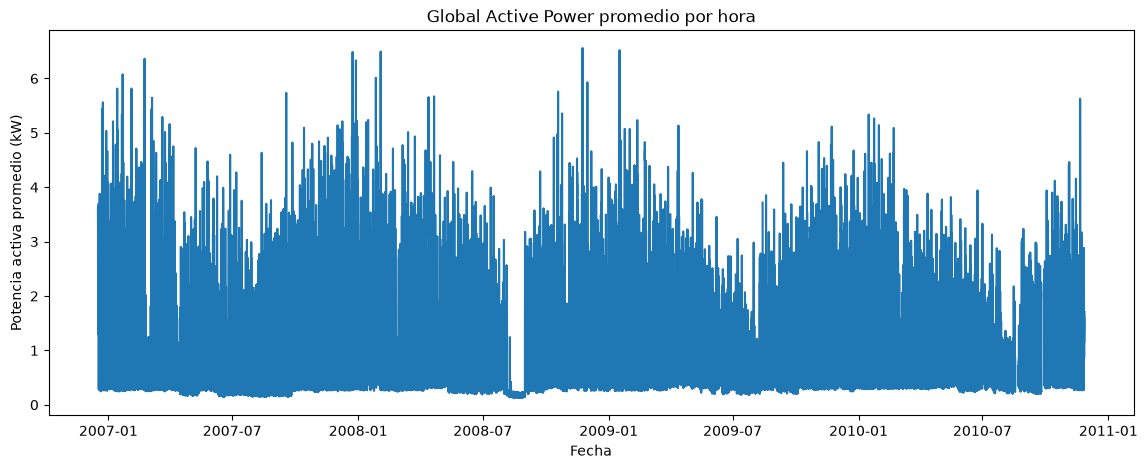

In [16]:
plt.figure(figsize=(14, 5))

plt.plot(
    df_hourly.index,
    df_hourly["Global_active_power"]
)

plt.title(
    "Global Active Power promedio por hora"
)
plt.xlabel("Fecha")
plt.ylabel("Potencia activa promedio (kW)")
plt.show()


**Hallazgos:** La serie horaria de Global_active_power presenta una elevada variabilidad de corto plazo, con períodos de consumo relativamente bajo y episodios de mayor demanda que alcanzan valores superiores a 4, 5 y 6 kW. Además, se observan cambios recurrentes en el nivel general de consumo a lo largo del período analizado. Visualmente, los niveles tienden a ser mayores en determinados períodos del año y menores en otros, lo que sugiere la presencia de una estructura temporal de mediano y largo plazo. Por esta razón, la serie no debe tratarse como si todas las horas tuvieran el mismo comportamiento esperado independientemente del momento del año.

## 6.2 Análisis de una semana

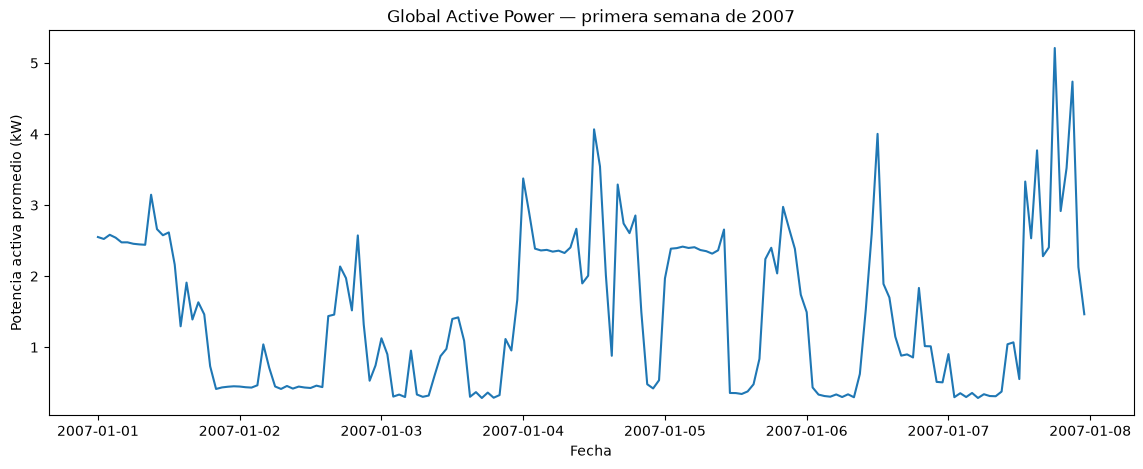

In [19]:
muestra_semana = df_hourly.loc[
    "2007-01-01":"2007-01-07"
]

plt.figure(figsize=(14, 5))

plt.plot(
    muestra_semana.index,
    muestra_semana["Global_active_power"]
)

plt.title(
    "Global Active Power — primera semana de 2007"
)
plt.xlabel("Fecha")
plt.ylabel("Potencia activa promedio (kW)")
plt.show()

**Hallazgos:** Al observar una semana a frecuencia horaria se aprecia una estructura intradiaria clara. El consumo alterna entre períodos de menor demanda y períodos con incrementos y picos, y estos comportamientos vuelven a presentarse a lo largo de los distintos días. Esto demuestra que las observaciones no son temporalmente independientes y respalda la decisión de trabajar a frecuencia horaria en lugar de diaria, ya que una agregación diaria eliminaría buena parte de esta información intradiaria.

## 6.3 Tendencia / Medias móviles

In [20]:
serie = df_hourly["Global_active_power"]

media_24h = serie.rolling(24).mean()

media_7d = serie.rolling(24 * 7).mean()

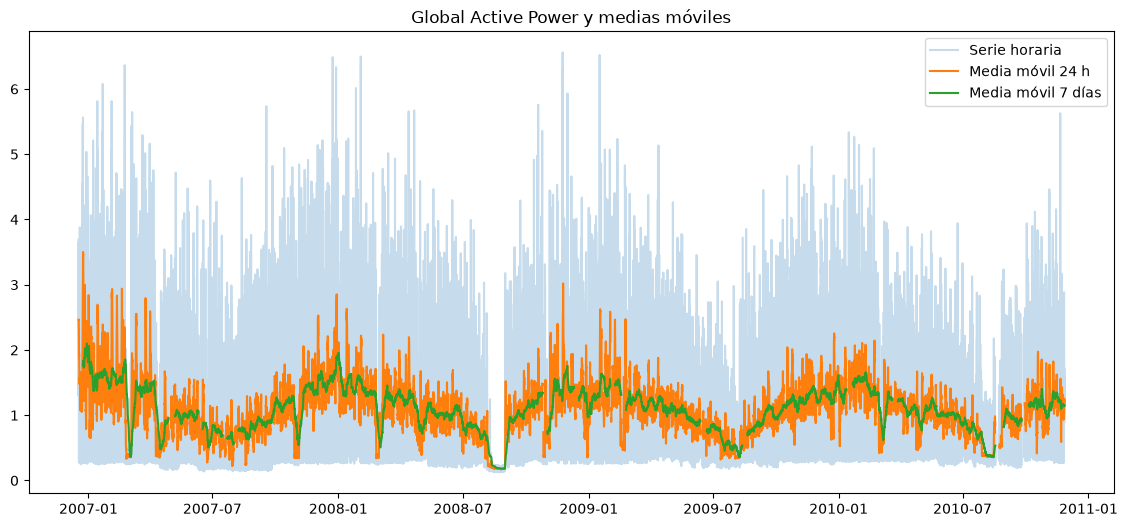

In [21]:
plt.figure(figsize=(14, 6))

plt.plot(
    serie.index,
    serie,
    alpha=0.25,
    label="Serie horaria"
)

plt.plot(
    media_24h.index,
    media_24h,
    label="Media móvil 24 h"
)

plt.plot(
    media_7d.index,
    media_7d,
    label="Media móvil 7 días"
)

plt.title(
    "Global Active Power y medias móviles"
)
plt.legend()
plt.show()

**Hallazgos:** La serie horaria presenta una fuerte variabilidad de corto plazo. La media móvil de 24 horas permite suavizar parte de esta variabilidad diaria, mientras que la media móvil de 7 días (168 horas) permite observar con mayor claridad la evolución del nivel promedio de consumo. No se identifica una tendencia monotónica sostenida de crecimiento o disminución durante todo el período. Sin embargo, sí se observa una estructura recurrente de mediano y largo plazo, con períodos de mayor y menor consumo que reaparecen a lo largo de los años. Esto sugiere la existencia de componentes estacionales además de la dinámica horaria.


## 6.4 Preparación de serie para diagnóstico


In [26]:
# Serie horaria original
serie = df_hourly["Global_active_power"]

# Identificar qué observaciones tienen un valor válido
es_valido = serie.notna()

# Crear identificadores para cada bloque continuo
bloque_id = (
    es_valido
    .ne(es_valido.shift())
    .cumsum()
)

# Calcular el tamaño de cada bloque continuo con datos válidos
tamano_bloques = (
    serie[es_valido]
    .groupby(bloque_id[es_valido])
    .size()
)

# Identificar el bloque continuo más largo
bloque_mas_largo = tamano_bloques.idxmax()

# Extraer únicamente ese bloque
serie_diagnostico = serie[
    es_valido
    & (bloque_id == bloque_mas_largo)
]

print("Inicio:", serie_diagnostico.index.min())
print("Fin:", serie_diagnostico.index.max())
print("Observaciones:", len(serie_diagnostico))

Inicio: 2007-08-01 09:00:00
Fin: 2008-10-25 09:00:00
Observaciones: 10825


In [32]:
# Verificación de Continuidad 
diferencias_tiempo = (
    serie_diagnostico
    .index
    .to_series()
    .diff()
    .dropna()
)

continuidad_horaria = (
    diferencias_tiempo
    == pd.Timedelta(hours=1)
).all()

print(
    "¿Todas las observaciones son consecutivas cada hora?",
    continuidad_horaria
)

¿Todas las observaciones son consecutivas cada hora? True


**Preparación para diagnóstico:** Para evitar que la eliminación directa de valores faltantes alterara la interpretación temporal de los lags, se identificó el bloque continuo más largo de observaciones horarias válidas. El bloque seleccionado contiene 10.825 observaciones consecutivas, desde el 1 de agosto de 2007 a las 09:00 hasta el 25 de octubre de 2008 a las 09:00. Se verificó además que todas las observaciones están separadas exactamente por una hora. Este bloque se utiliza exclusivamente para los diagnósticos ACF, PACF y ADF, garantizando que, por ejemplo, un lag de 24 represente efectivamente 24 horas.

## 6.5 ACF

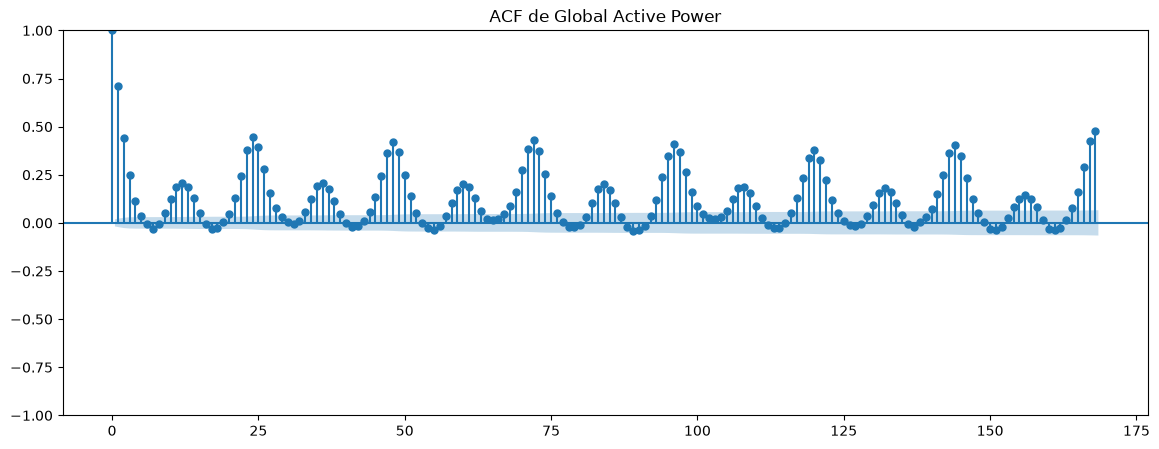

In [27]:
fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(
    serie_diagnostico,
    lags=168,
    ax=ax
)

plt.title(
    "ACF de Global Active Power"
)
plt.show()

**Hallazgos:** La función de autocorrelación muestra una dependencia temporal importante entre observaciones consecutivas. El lag 1 presenta una autocorrelación cercana a 0.71, indicando que el nivel observado en la hora anterior contiene información relevante sobre el consumo de la hora actual. La autocorrelación disminuye conforme aumenta la distancia temporal inmediata, pero vuelve a incrementarse aproximadamente cada 24 horas. Este patrón periódico constituye evidencia de una estructura estacional diaria. Además, el comportamiento se mantiene en múltiplos de 24 horas hasta alcanzar 168 horas, correspondientes a una semana.


## 6.6 Autocorrelaciones de lags relevantes

In [31]:
lags_interes = [
    1,
    2,
    24,
    48,
    72,
    168,
]

autocorrelaciones = pd.DataFrame({
    "Lag_horas": lags_interes,
    "Interpretacion": [
        "Hora anterior",
        "Dos horas anteriores",
        "Misma hora del día anterior",
        "Misma hora de hace dos días",
        "Misma hora de hace tres días",
        "Misma hora de la semana anterior",
    ],
    "Autocorrelacion": [
        serie_diagnostico.autocorr(lag=lag)
        for lag in lags_interes
    ],
})

display(autocorrelaciones)

,Lag_horas,Interpretacion,Autocorrelacion
0,1,Hora anterior,0.709967
1,2,Dos horas anteriores,0.442376
2,24,Misma hora del día anterior,0.447157
3,48,Misma hora de hace dos días,0.421594
4,72,Misma hora de hace tres días,0.434201
5,168,Misma hora de la semana anterior,0.487195


Los lags seleccionados confirman cuantitativamente los patrones observados en la ACF. La mayor autocorrelación corresponde al lag 1 (0.710), lo que evidencia una fuerte persistencia de corto plazo. El lag 24 presenta una autocorrelación de 0.447, respaldando la existencia de una periodicidad diaria. El lag 168 alcanza aproximadamente 0.487, lo que aporta evidencia adicional de una estructura semanal. Estos resultados justifican evaluar lag_1, lag_24 y lag_168 como características predictoras durante el Feature Engineering.

## 6.7 PACF

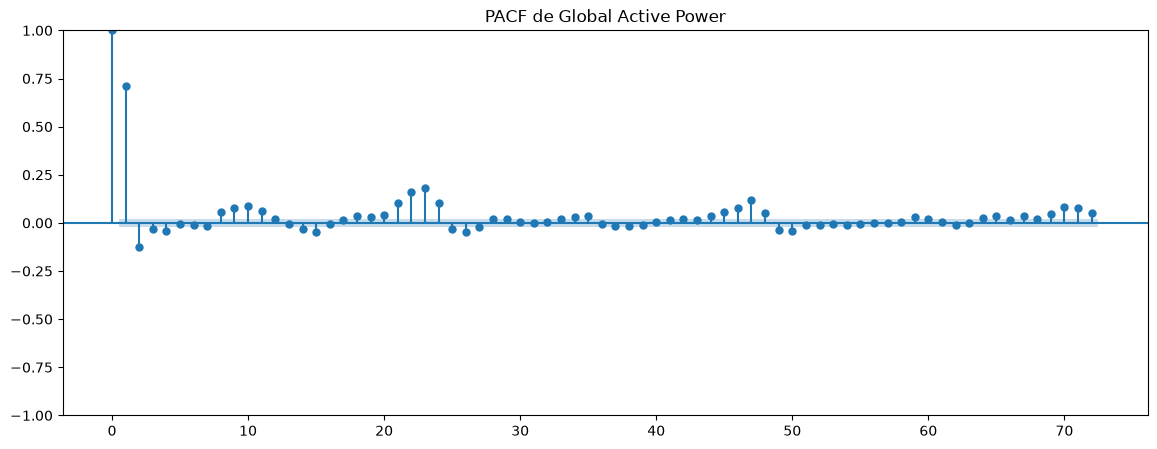

In [28]:
fig, ax = plt.subplots(figsize=(14, 5))

plot_pacf(
    serie_diagnostico,
    lags=72,
    method="ywm",
    ax=ax
)

plt.title(
    "PACF de Global Active Power"
)
plt.show()

**Hallazgos:** La PACF confirma que el lag 1 posee la relación directa más fuerte con el consumo actual. Una vez controlado el efecto de los lags intermedios, las asociaciones restantes son considerablemente menores. Sin embargo, persisten estructuras alrededor de 24, 48 y 72 horas, lo cual es coherente con el patrón diario identificado mediante la ACF. La combinación de ACF y PACF refuerza la importancia de la dependencia inmediatamente anterior y de los componentes estacionales diarios.

## 6.8 Estacionariedad - ADF

In [29]:
resultado_adf = adfuller(
    serie_diagnostico,
    autolag="AIC"
)

print(
    "ADF Statistic:",
    resultado_adf[0]
)

print(
    "p-value:",
    resultado_adf[1]
)

print(
    "Critical Values:"
)

for clave, valor in resultado_adf[4].items():
    print(
        f"  {clave}: {valor}"
    )

ADF Statistic: -9.210139197480382
p-value: 1.8974838789771092e-15
Critical Values:
  1%: -3.4309563647738046
  5%: -2.861807979313397
  10%: -2.5669126402527156


**Hallazgos:** La prueba Augmented Dickey-Fuller aplicada al bloque horario continuo utilizado para diagnóstico produjo un estadístico ADF de -9.210 y un p-value aproximado de \(1.90\times10^{-15}\). Este valor es considerablemente inferior al nivel de significancia de 0.05. Además, el estadístico ADF es más negativo que los valores críticos correspondientes al 1%, 5% y 10%. Por lo tanto, se rechaza la hipótesis nula de presencia de raíz unitaria en el bloque analizado. Este resultado indica que no existe evidencia de una tendencia estocástica que haga necesaria una primera diferenciación para los modelos inicialmente considerados.

## 6.9 Conclusiones

El análisis de la serie muestra que el consumo eléctrico cambia bastante entre horas y que existen patrones que se repiten con el tiempo.

La ACF mostró que el consumo de una hora está relacionado con horas anteriores. Los resultados más importantes fueron:

lag_1: 0.710
lag_24: 0.447
lag_168: 0.487

Esto indica que la hora anterior, la misma hora del día anterior y la misma hora de la semana anterior pueden aportar información útil para realizar el pronóstico.

La PACF también mostró que el lag_1 tiene una relación importante con el consumo actual y que existen patrones alrededor de las 24 horas.

Por último, la prueba ADF obtuvo un p-value mucho menor a 0.05, por lo que se rechaza la hipótesis de raíz unitaria. Por esta razón, inicialmente no se realizará diferenciación de la serie.

# 7. Feature Engineering